In [1]:
import os, time, threading, gc, tracemalloc, warnings
import numpy as np
import polars as pl
import psutil

warnings.filterwarnings('ignore')


class Profiler:
    """RSS peak (process-wide) + tracemalloc peak (python heap) + wall time."""

    def __init__(self, interval=0.05):
        self.interval = interval
        self.proc = psutil.Process(os.getpid())

    def __enter__(self):
        gc.collect()
        self.rss_baseline = self.proc.memory_info().rss
        self.rss_peak = self.rss_baseline
        self._stop = False
        self._thread = threading.Thread(target=self._sample, daemon=True)
        self._thread.start()
        tracemalloc.start()
        self.t0 = time.perf_counter()
        return self

    def _sample(self):
        while not self._stop:
            rss = self.proc.memory_info().rss
            if rss > self.rss_peak:
                self.rss_peak = rss
            time.sleep(self.interval)

    def __exit__(self, *exc):
        self.elapsed = time.perf_counter() - self.t0
        _, self.tracemalloc_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        self._stop = True
        self._thread.join()
        self.rss_delta = self.rss_peak - self.rss_baseline

    def report(self, label):
        mb = 1024 ** 2
        print(f"{label:<10} time={self.elapsed:7.3f}s  "
              f"RSS Δpeak={self.rss_delta/mb:7.1f} MB  "
              f"tracemalloc peak={self.tracemalloc_peak/mb:7.1f} MB")

In [2]:
# 데이터 로드 (파주 지점, 최근 60일 = 1,440h)
df = pl.read_csv("/Users/icy71/GitHub/Rust-python-arima/rustima/0_Example_cy/total_heat_demand_dwh.csv")
df_paju = (
    df.filter(pl.col('branch_id') == '파주')
      .with_columns(pl.col('date').str.to_datetime())
      .sort('date')
)
y_sub = df_paju['heat_demand'].tail(60 * 24).to_numpy().astype(np.float64)
print(f"비교 데이터: n={len(y_sub)}h, s=24")

비교 데이터: n=1440h, s=24


## stepwise = True

In [5]:
from rustima import auto_arima as rs_auto

with Profiler() as p_rs:
    auto_rs = rs_auto(y_sub, s=24, trend='n', stepwise=True, trace=False)

rs_order    = auto_rs.order
rs_seasonal = auto_rs.seasonal_order
rs_aic      = float(auto_rs.result.aic)

p_rs.report("rustima")
print(f"           order={rs_order}{rs_seasonal}  AIC={rs_aic:.2f}")

rustima    time= 30.078s  RSS Δpeak=  125.3 MB  tracemalloc peak=   60.6 MB
           order=(1, 0, 1)(1, 1, 1, 24)  AIC=8853.09


In [6]:
import pmdarima as pm

with Profiler() as p_pm:
    auto_pm = pm.auto_arima(
        y_sub,
        seasonal=True, m=24, trend=None,
        stepwise=True, suppress_warnings=True,
    )

pm_order    = auto_pm.order
pm_seasonal = auto_pm.seasonal_order
pm_aic      = float(auto_pm.aic())

p_pm.report("pmdarima")
print(f"           order={pm_order}{pm_seasonal}  AIC={pm_aic:.2f}")

pmdarima   time=178.087s  RSS Δpeak= 5193.7 MB  tracemalloc peak=16531.8 MB
           order=(4, 1, 1)(2, 0, 0, 24)  AIC=9190.66


In [7]:
def fmt_mb(b):
    return f"{b/1024**2:7.1f} MB"

print("=" * 86)
print(f"{'engine':<10}{'order':<14}{'seasonal':<16}"
      f"{'AIC':>10}{'time(s)':>10}{'RSS Δpeak':>14}{'PyHeap peak':>14}")
print("-" * 86)
print(f"{'rustima':<10}{str(rs_order):<14}{str(rs_seasonal):<16}"
      f"{rs_aic:>10.2f}{p_rs.elapsed:>10.3f}{fmt_mb(p_rs.rss_delta):>14}{fmt_mb(p_rs.tracemalloc_peak):>14}")
print(f"{'pmdarima':<10}{str(pm_order):<14}{str(pm_seasonal):<16}"
      f"{pm_aic:>10.2f}{p_pm.elapsed:>10.3f}{fmt_mb(p_pm.rss_delta):>14}{fmt_mb(p_pm.tracemalloc_peak):>14}")
print("=" * 86)

speedup   = p_pm.elapsed / p_rs.elapsed if p_rs.elapsed > 0 else float('inf')
rss_ratio = p_pm.rss_delta / p_rs.rss_delta if p_rs.rss_delta > 0 else float('inf')
heap_ratio = p_pm.tracemalloc_peak / p_rs.tracemalloc_peak if p_rs.tracemalloc_peak > 0 else float('inf')

print(f"속도        : rustima 가 {speedup:6.1f}x 빠름  (절감 {p_pm.elapsed - p_rs.elapsed:+.2f}s)")
print(f"RSS 피크 비 : pmdarima / rustima = {rss_ratio:6.2f}x")
print(f"PyHeap 비   : pmdarima / rustima = {heap_ratio:6.2f}x   (rustima의 Rust 측 할당은 미포함)")
print(f"AIC 차      : pmdarima - rustima = {pm_aic - rs_aic:+.2f}")
print(f"order       : {'동일' if (rs_order == pm_order and rs_seasonal == pm_seasonal) else '다름'}")

engine    order         seasonal               AIC   time(s)     RSS Δpeak   PyHeap peak
--------------------------------------------------------------------------------------
rustima   (1, 0, 1)     (1, 1, 1, 24)      8853.09    30.078      125.3 MB       60.6 MB
pmdarima  (4, 1, 1)     (2, 0, 0, 24)      9190.66   178.087     5193.7 MB    16531.8 MB
속도        : rustima 가    5.9x 빠름  (절감 +148.01s)
RSS 피크 비 : pmdarima / rustima =  41.45x
PyHeap 비   : pmdarima / rustima = 272.79x   (rustima의 Rust 측 할당은 미포함)
AIC 차      : pmdarima - rustima = +337.57
order       : 다름


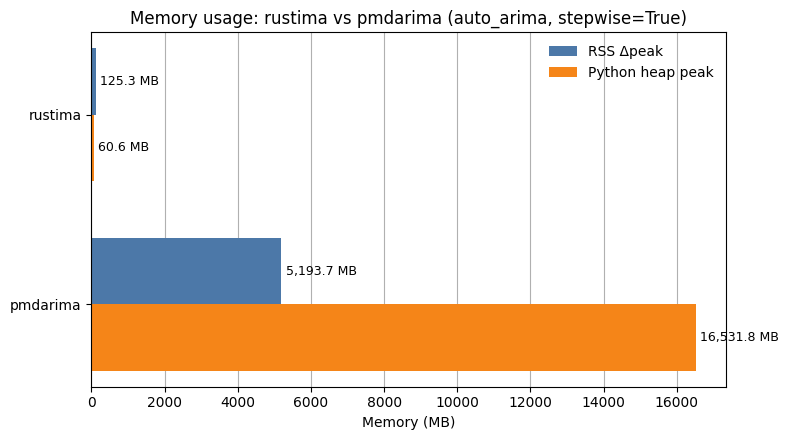

In [9]:
import matplotlib.pyplot as plt
import numpy as np

mb = 1024 ** 2
engines = ['rustima', 'pmdarima']
rss_vals    = [p_rs.rss_delta / mb,         p_pm.rss_delta / mb]
pyheap_vals = [p_rs.tracemalloc_peak / mb,  p_pm.tracemalloc_peak / mb]

y = np.arange(len(engines))
height = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.barh(y - height/2, rss_vals,    height, label='RSS Δpeak',        color='#4C78A8')
b2 = ax.barh(y + height/2, pyheap_vals, height, label='Python heap peak', color='#F58518')

ax.set_xlabel('Memory (MB)')
ax.set_title('Memory usage: rustima vs pmdarima (auto_arima, stepwise=True)')
ax.set_yticks(y)
ax.set_yticklabels(engines)
ax.invert_yaxis()
ax.grid(True, axis='x')
ax.set_axisbelow(True)
ax.legend(frameon=False)

for bars in (b1, b2):
    for rect in bars:
        w = rect.get_width()
        ax.annotate(f'{w:,.1f} MB',
                    xy=(w, rect.get_y() + rect.get_height() / 2),
                    xytext=(3, 0), textcoords='offset points',
                    ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

                                                                                                                                                                                                             
  RSS peak / Python heap peak 의 의미                       
                                                                                                             
  둘 다 "이 코드 블록이 돌아가는 동안 최고점에서 얼마나 많은 메모리를 썼는가" 를 보지만, 어느 층위 를
  보느냐가 다릅니다.                                                                                         
                                                            
  RSS Δpeak (psutil 기반)                                                                                    
                                                            
  - RSS = Resident Set Size: OS 가 보기에 이 프로세스가 실제 물리 RAM 에 올려두고 있는 양.                   
  - Profiler 는 0.05 초 간격으로 별도 스레드에서 proc.memory_info().rss 를 찍으며 최댓값을 기록.
  - Δpeak = peak − baseline 이라 이번 작업으로 늘어난 증분 만 본다 (이미 로드돼 있던 파이썬/라이브러리 자체는
   제외).                                                                                                    
  - 포함 대상: Python 객체, NumPy 배열의 C 버퍼, BLAS/LAPACK 워크스페이스, rustima 의 Rust 쪽 할당, 공유     
  라이브러리, 내부 캐시 등 프로세스 전체가 쓰는 모든 것.                                                     
  - OS 단에서 관측하는 "진짜로 RAM 점유한 양" → 실서버에서 OOM 터지나/안 터지나 를 예측할 때 보는 값.
                                                                                                             
  Python heap peak (tracemalloc 기반)                       
                                                                                                             
  - tracemalloc 은 CPython 의 메모리 할당자(PyMem_*) 를 후킹해서 파이썬이 요청한 할당만 추적.                
  - 따라서 파이썬 객체(list, dict, ndarray 의 Python wrapper 등) 가 쓴 heap 만 집계.
  - 제외 대상: Rust/C 확장에서 자체 allocator 로 잡은 메모리 (rustima 의 Rust 본체, BLAS 의 내부 버퍼 등) 는 
  여기에 안 잡힘.                                                                                            
  - 그래서 rustima 의 60.6 MB 는 "Python 에서 본 부분만" 이고, 실제 할당은 RSS (125 MB) 쪽이 더 정확.        
                                                                                                             
  이번 비교에서의 해석                                                                                       
                                                                                                             
  - pmdarima 는 순수 Python/NumPy 구현 → Rust 레이어가 없으므로 두 지표가 비슷한 층을 본다. 그런데도 PyHeap  
  16.5 GB 가 나온 건 탐색 과정에서 모델 객체/배열을 반복적으로 할당/해제한 누적 피크.
  - rustima 는 실제 계산이 Rust 에 내려가서 Python heap 에는 얇은 wrapper만 남는 구조 → PyHeap(60 MB) 이 작게
   찍히고, RSS(125 MB) 가 "Rust 쪽까지 포함한 실제 메모리" 에 더 가까움.                                     
  - 그래서 주석 "rustima의 Rust 측 할당은 미포함" 은 PyHeap 지표에만 적용되는 이야기입니다.

## Grid search

In [10]:
from rustima import auto_arima as rs_auto

with Profiler() as p_rs:
    auto_rs = rs_auto(y_sub, s=24, trend='n', stepwise=False, trace=False)

rs_order    = auto_rs.order
rs_seasonal = auto_rs.seasonal_order
rs_aic      = float(auto_rs.result.aic)

p_rs.report("rustima")
print(f"           order={rs_order}{rs_seasonal}  AIC={rs_aic:.2f}")

rustima    time=418.054s  RSS Δpeak=   22.8 MB  tracemalloc peak=    1.5 MB
           order=(3, 0, 5)(1, 1, 2, 24)  AIC=8777.51


In [ ]:
import pmdarima as pm

with Profiler() as p_pm:
    auto_pm = pm.auto_arima(
        y_sub,
        seasonal=True, m=24, trend=None,
        stepwise=False, suppress_warnings=True,
    )

pm_order    = auto_pm.order
pm_seasonal = auto_pm.seasonal_order
pm_aic      = float(auto_pm.aic())

p_pm.report("pmdarima")
print(f"order={pm_order}{pm_seasonal}  AIC={pm_aic:.2f}")

pmdarima   time=171.737s  RSS Δpeak= 6505.1 MB  tracemalloc peak=20422.3 MB
           order=(2, 1, 1)(2, 0, 0, 24)  AIC=9192.46


In [12]:
def fmt_mb(b):
    return f"{b/1024**2:7.1f} MB"

print("=" * 86)
print(f"{'engine':<10}{'order':<14}{'seasonal':<16}"
      f"{'AIC':>10}{'time(s)':>10}{'RSS Δpeak':>14}{'PyHeap peak':>14}")
print("-" * 86)
print(f"{'rustima':<10}{str(rs_order):<14}{str(rs_seasonal):<16}"
      f"{rs_aic:>10.2f}{p_rs.elapsed:>10.3f}{fmt_mb(p_rs.rss_delta):>14}{fmt_mb(p_rs.tracemalloc_peak):>14}")
print(f"{'pmdarima':<10}{str(pm_order):<14}{str(pm_seasonal):<16}"
      f"{pm_aic:>10.2f}{p_pm.elapsed:>10.3f}{fmt_mb(p_pm.rss_delta):>14}{fmt_mb(p_pm.tracemalloc_peak):>14}")
print("=" * 86)

speedup   = p_pm.elapsed / p_rs.elapsed if p_rs.elapsed > 0 else float('inf')
rss_ratio = p_pm.rss_delta / p_rs.rss_delta if p_rs.rss_delta > 0 else float('inf')
heap_ratio = p_pm.tracemalloc_peak / p_rs.tracemalloc_peak if p_rs.tracemalloc_peak > 0 else float('inf')

print(f"속도        : rustima 가 {speedup:6.1f}x 빠름  (절감 {p_pm.elapsed - p_rs.elapsed:+.2f}s)")
print(f"RSS 피크 비 : pmdarima / rustima = {rss_ratio:6.2f}x")
print(f"PyHeap 비   : pmdarima / rustima = {heap_ratio:6.2f}x   (rustima의 Rust 측 할당은 미포함)")
print(f"AIC 차      : pmdarima - rustima = {pm_aic - rs_aic:+.2f}")
print(f"order       : {'동일' if (rs_order == pm_order and rs_seasonal == pm_seasonal) else '다름'}")

engine    order         seasonal               AIC   time(s)     RSS Δpeak   PyHeap peak
--------------------------------------------------------------------------------------
rustima   (3, 0, 5)     (1, 1, 2, 24)      8777.51   418.054       22.8 MB        1.5 MB
pmdarima  (2, 1, 1)     (2, 0, 0, 24)      9192.46   171.737     6505.1 MB    20422.3 MB
속도        : rustima 가    0.4x 빠름  (절감 -246.32s)
RSS 피크 비 : pmdarima / rustima = 285.54x
PyHeap 비   : pmdarima / rustima = 13408.47x   (rustima의 Rust 측 할당은 미포함)
AIC 차      : pmdarima - rustima = +414.96
order       : 다름


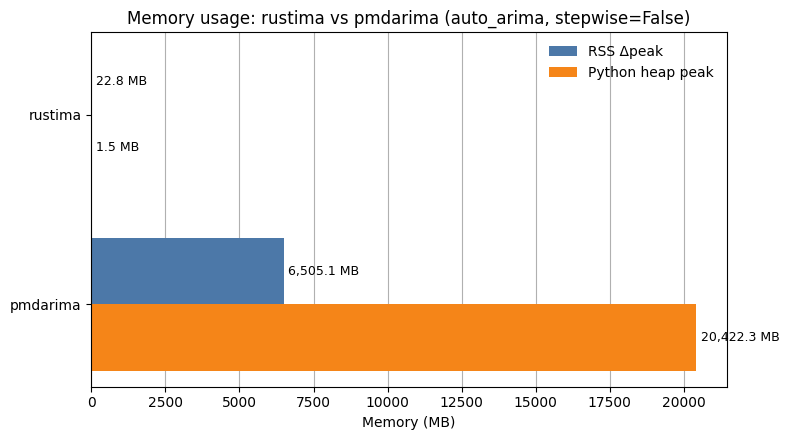

In [14]:
mb = 1024 ** 2
engines = ['rustima', 'pmdarima']
rss_vals    = [p_rs.rss_delta / mb,         p_pm.rss_delta / mb]
pyheap_vals = [p_rs.tracemalloc_peak / mb,  p_pm.tracemalloc_peak / mb]

y = np.arange(len(engines))
height = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.barh(y - height/2, rss_vals,    height, label='RSS Δpeak',        color='#4C78A8')
b2 = ax.barh(y + height/2, pyheap_vals, height, label='Python heap peak', color='#F58518')

ax.set_xlabel('Memory (MB)')
ax.set_title('Memory usage: rustima vs pmdarima (auto_arima, stepwise=False)')
ax.set_yticks(y)
ax.set_yticklabels(engines)
ax.invert_yaxis()
ax.grid(True, axis='x')
ax.set_axisbelow(True)
ax.legend(frameon=False)

for bars in (b1, b2):
    for rect in bars:
        w = rect.get_width()
        ax.annotate(f'{w:,.1f} MB',
                    xy=(w, rect.get_y() + rect.get_height() / 2),
                    xytext=(3, 0), textcoords='offset points',
                    ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Grid 같은 조건에서 실행

In [ ]:
from rustima import auto_arima as rs_auto

with Profiler() as p_rs:
    auto_rs = rs_auto(y_sub, s=24, trend='n', stepwise=False, trace=False)

rs_order    = auto_rs.order
rs_seasonal = auto_rs.seasonal_order
rs_aic      = float(auto_rs.result.aic)

p_rs.report("rustima")
print(f"           order={rs_order}{rs_seasonal}  AIC={rs_aic:.2f}")

In [ ]:
import pmdarima as pm

with Profiler() as p_pm:
    auto_pm = pm.auto_arima(
        y_sub,
        max_p=5, max_q=5,                                                                          
        max_P=2, max_Q=2,
        seasonal=True, m=24, trend=None,
        stepwise=False, suppress_warnings=True,
    )                                                                                             

pm_order    = auto_pm.order
pm_seasonal = auto_pm.seasonal_order
pm_aic      = float(auto_pm.aic())

p_pm.report("pmdarima")
print(f"order={pm_order}{pm_seasonal}  AIC={pm_aic:.2f}")

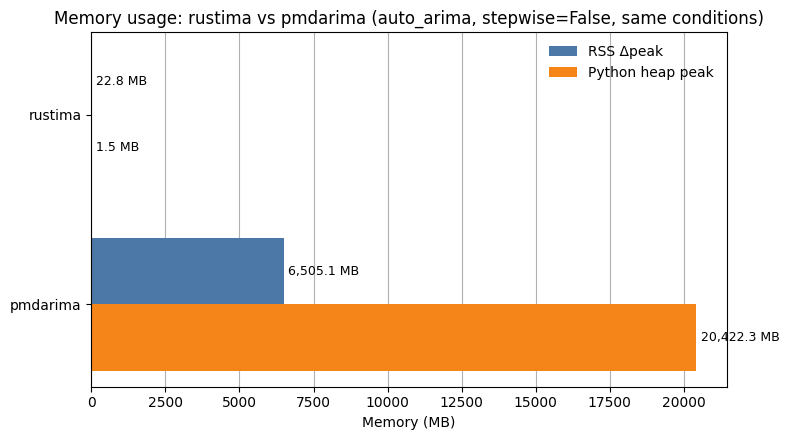

In [15]:
mb = 1024 ** 2
engines = ['rustima', 'pmdarima']
rss_vals    = [p_rs.rss_delta / mb,         p_pm.rss_delta / mb]
pyheap_vals = [p_rs.tracemalloc_peak / mb,  p_pm.tracemalloc_peak / mb]

y = np.arange(len(engines))
height = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.barh(y - height/2, rss_vals,    height, label='RSS Δpeak',        color='#4C78A8')
b2 = ax.barh(y + height/2, pyheap_vals, height, label='Python heap peak', color='#F58518')

ax.set_xlabel('Memory (MB)')
ax.set_title('Memory usage: rustima vs pmdarima (auto_arima, stepwise=False, same conditions)')
ax.set_yticks(y)
ax.set_yticklabels(engines)
ax.invert_yaxis()
ax.grid(True, axis='x')
ax.set_axisbelow(True)
ax.legend(frameon=False)

for bars in (b1, b2):
    for rect in bars:
        w = rect.get_width()
        ax.annotate(f'{w:,.1f} MB',
                    xy=(w, rect.get_y() + rect.get_height() / 2),
                    xytext=(3, 0), textcoords='offset points',
                    ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()